### Prototipo geocoder

Notebook para prototipar a função de geocodificação de endereços.

A função se baseará na camada de logradouros do GeoSampa (posteriormente podendo ser migrada para as camadas internas do MDSF).

A geocodificação partirá do código do logradouro já identificado anteriormente no APP (posteriormente podemos implementar o fluxo completo, com a identificação do logradouro pelo nome, como um serviço em si mesmo).

O fluxo de processamento de dados é o seguinte:

1. Pelo WFS, obter todos os segmentos de reta relacionados ao CODLOG;
2. Remover os segmentos de reta que não possuem numeração no lado par e no lado ímpar (ocorre em alguns casos em que, por exemplo, uma rotatória foi representada, ou outra estrutura como canteiro central)
3. Identificar a paridade da numeração inputada pelo usuário (se é par ou ímpar)
4. Identificar o segmento de reta que contém a numeração indicada pelo usuário
    - Casoa não encontre retorna mensagem de erro
5. Arrumar a orientação do segmento de reta:
    - Identificar o segmento de reta que tem a numeração (para a paridade) logo antes
        - Caso seja o segmento inicial, tem que inverter a lógica para o segmento logo depois. Isso podemos identificar verificando se o numero inicial é o menor para aquela paridade
    - Verificar se o ponto inicial do segmento de reta de interesse está mais próximo do ponto final do segmento de reta anterior ou do ponto inicial
        - Inverter se for o segmento inicial (aí o ponto final do logradouro tem que estar próximo do inicial do outro - podemos fazer isso espertamente trocando id por ego nos parametros da função)
    - Se estiver mais próximo do ponto final, a orientação está correta, não precisa fazer nada. Se estiver mais próximo do ponto inicial, a orientação está errada, então precisa inverter as coordenadas
6. Interpolar a numeração dentro do segmento de reta ordenado
7. Gerar o ponto
8. Retornar a resposta com metadados (usar um modelo Pydantic)

In [1]:
from api.integrations.wfs import WFSFetcher
from enum import Enum
from api.config import settings
import geopandas as gpd
from typing import cast, Dict
from shapely.geometry import LineString, Point
import math

class Paridade(Enum):
    IMPAR = 1
    PAR = 2


class SegmentoNotFoundError(Exception):
    pass

class NumeracaoNotFoundError(Exception):
    pass

class SolverOrientacaoSegmento:

    def __init__(self, cols_numeracao: Dict[Paridade, dict[str, str]])->None:
        self.cols_numeracao = cols_numeracao

    def is_primeiro_segmento(self, gdf_segmentos:gpd.GeoDataFrame, segmento:gpd.GeoDataFrame, paridade:Paridade)->bool:

        coluna_inicial = self.cols_numeracao[paridade]["inicial"]

        numero_inicial_segmento = segmento.iloc[0][coluna_inicial]

        #menor numero inicial
        menor_numero_inicial = gdf_segmentos[coluna_inicial].min()

        return numero_inicial_segmento == menor_numero_inicial
    
    def is_ultimo_segmento(self, gdf_segmentos:gpd.GeoDataFrame, segmento:gpd.GeoDataFrame, paridade:Paridade)->bool:

        coluna_final = self.cols_numeracao[paridade]["final"]

        numero_final_segmento = segmento.iloc[0][coluna_final]

        #maior numero final
        maior_numero_final = gdf_segmentos[coluna_final].max()

        return numero_final_segmento == maior_numero_final
    
    def segmentos_anteriores(self, gdf_segmentos:gpd.GeoDataFrame, segmento:gpd.GeoDataFrame, paridade:Paridade)->gpd.GeoDataFrame:

        if self.is_primeiro_segmento(gdf_segmentos, segmento, paridade):
            raise ValueError("Segmento é o primeiro da via, não existe segmento anterior")
        coluna_inicial = self.cols_numeracao[paridade]["inicial"]
        coluna_final = self.cols_numeracao[paridade]["final"]
        numero_inicial_segmento = segmento.iloc[0][coluna_inicial]

        #nao deveria ser menor ou igual (só menor) mas estou colocando por precaução
        segmentos_anteriores = gdf_segmentos[gdf_segmentos[coluna_final] <= numero_inicial_segmento] 
        segmentos_anteriores.sort_values(by=coluna_final, ascending=False, inplace=True)
        return segmentos_anteriores
    
    def segmentos_posteriores(self, gdf_segmentos:gpd.GeoDataFrame, segmento:gpd.GeoDataFrame, paridade:Paridade)->gpd.GeoDataFrame:
        
        if self.is_ultimo_segmento(gdf_segmentos, segmento, paridade):
            raise ValueError("Segmento é o último da via, não existe segmento posterior")
        coluna_inicial = self.cols_numeracao[paridade]["inicial"]
        coluna_final = self.cols_numeracao[paridade]["final"]
        numero_final_segmento = segmento.iloc[0][coluna_final]

        #nao deveria ser maior ou igual (só maior) mas estou colocando por precaução
        segmentos_posteriores = gdf_segmentos[gdf_segmentos[coluna_inicial] >= numero_final_segmento] 
        segmentos_posteriores.sort_values(by=coluna_inicial, ascending=True, inplace=True)
        return segmentos_posteriores

    def segmento_adjacente(self, gdf_segmentos:gpd.GeoDataFrame, segmento:gpd.GeoDataFrame, paridade:Paridade)->gpd.GeoDataFrame:

        if self.is_primeiro_segmento(gdf_segmentos, segmento, paridade):
            segmentos_adjacentes = self.segmentos_posteriores(gdf_segmentos, segmento, paridade)

        else:
            segmentos_adjacentes = self.segmentos_anteriores(gdf_segmentos, segmento, paridade)

        return segmentos_adjacentes.iloc[[0]]
    

    def orientacao_segmento_is_correta(self, segmento:gpd.GeoDataFrame, gdf_segmentos:gpd.GeoDataFrame, paridade:Paridade)->bool:

        segmento_adjacente = self.segmento_adjacente(gdf_segmentos, segmento, paridade)
        geom_segmento = cast(LineString, segmento.geometry.iloc[0])
        geom_segmento_adjacente = cast(LineString, segmento_adjacente.geometry.iloc[0])
        
        if self.is_primeiro_segmento(gdf_segmentos, segmento, paridade):
            #se é o primeiro segmento, pego a última coordenada dele e verifico se está próxima da primeira do segmento adjacente
            ponto_referencia_ego = geom_segmento.coords[-1]
            ponto_proximo_alter = geom_segmento_adjacente.coords[0]
            ponto_distante_alter= geom_segmento_adjacente.coords[-1]
        else:
            #se não é o primeiro segmento, aí pego a primeira coordenada do segmento e verifico se está próxima da última do segmento adjacente
            ponto_referencia_ego = geom_segmento.coords[0]
            ponto_proximo_alter = geom_segmento_adjacente.coords[-1]
            ponto_distante_alter= geom_segmento_adjacente.coords[0]

        
        distancia_proximo = math.dist(ponto_referencia_ego, ponto_proximo_alter)
        distancia_distante = math.dist(ponto_referencia_ego, ponto_distante_alter)
        
        if distancia_distante < distancia_proximo:
            return False
            
        return True
    
    def corrigir_orientacao_segmento(self, segmento:gpd.GeoDataFrame, gdf_segmentos:gpd.GeoDataFrame, paridade:Paridade)->gpd.GeoDataFrame:
        

        if self.orientacao_segmento_is_correta(segmento, gdf_segmentos, paridade):
            return segmento
        geom_segmento = cast(LineString, segmento.geometry.iloc[0])
        coordenadas_invertidas = list(geom_segmento.coords)[::-1]
        nova_geometria = LineString(coordenadas_invertidas)
        geometrias = segmento.geometry.tolist()
        geometrias[0] = nova_geometria
        segmento = segmento.set_geometry(geometrias)
        return segmento
    
    def __call__(self, segmento:gpd.GeoDataFrame, gdf_segmentos:gpd.GeoDataFrame, paridade:Paridade)->gpd.GeoDataFrame:
        return self.corrigir_orientacao_segmento(segmento, gdf_segmentos, paridade)



class DimapGeocoder:

    cols_numeracao = {
        Paridade.PAR: {
        "inicial" :   'cd_numero_inicial_par',
        "final" : 'cd_numero_final_par'     
    },
    Paridade.IMPAR: {
        "inicial" : 'cd_numero_inicial_impar',
        "final" : 'cd_numero_final_impar'
    }
    }

    def __init__(self)->None:

        self.wfs = WFSFetcher()
        self.layer_logradouros = settings.LAYER_LOGRADOUROS
        self.corrigir_orientacao_segmento = SolverOrientacaoSegmento(self.cols_numeracao)

    @property
    def cols_numeracao_lst(self):
        cols = []
        for paridade in Paridade:
            cols.extend(self.cols_numeracao[paridade].values())
        return cols

    def get_segmentos(self, codlog:int)->gpd.GeoDataFrame:

        segmentos = []

        for batch in self.wfs(self.layer_logradouros, cql_filter=f"codlog={codlog}"):
            segmentos.extend(batch)

        gdf_segmentos = gpd.GeoDataFrame.from_features(segmentos)

        if gdf_segmentos.empty:
            #usando erro especifico para poder dar catch depois e retornar 404
            raise SegmentoNotFoundError(f"Nenhum segmento encontrado para codlog={codlog}")

        return gdf_segmentos
    
    def paridade_numeracao(self, numero:int)->Paridade:

        if numero % 2 == 0:
            return Paridade.PAR
        else:
            return Paridade.IMPAR
        
    def clean_segmentos_sem_numeracao(self, gdf_segmentos:gpd.GeoDataFrame)->gpd.GeoDataFrame:

       df_numeracao = gdf_segmentos[self.cols_numeracao_lst]
       sem_numeracao_nenhum_lado = df_numeracao.isnull().all(axis=1)
       return gdf_segmentos[~sem_numeracao_nenhum_lado]
    

    def find_segmento_contem_numero(self, gdf_segmentos:gpd.GeoDataFrame, numero:int, paridade:Paridade)->gpd.GeoDataFrame:

        col_inicial = self.cols_numeracao[paridade]["inicial"]
        col_final = self.cols_numeracao[paridade]["final"]

        #filtrando segmentos que contem o numero buscado
        gdf_segmentos_contem_numero = gdf_segmentos[
            (gdf_segmentos[col_inicial] <= numero) & 
            (gdf_segmentos[col_final] >= numero)
        ]

        if gdf_segmentos_contem_numero.empty:
            raise NumeracaoNotFoundError(f"Nenhum segmento encontrado contendo o numero {numero}")

        if gdf_segmentos_contem_numero.shape[0] > 1:
            print(f"Warning: mais de um segmento encontrado contendo o numero {numero}. Retornando o primeiro.")
            gdf_segmentos_contem_numero = gdf_segmentos_contem_numero.iloc[[0]]

        return gdf_segmentos_contem_numero
    
    def interpolar_numero_da_rua(self, segmento:gpd.GeoDataFrame, numero:int, paridade:Paridade)->Point:

        coluna_inicial = self.cols_numeracao[paridade]["inicial"]
        coluna_final = self.cols_numeracao[paridade]["final"]

        numero_inicial = segmento.iloc[0][coluna_inicial]
        numero_final = segmento.iloc[0][coluna_final]

        geom_segmento = cast(LineString, segmento.geometry.iloc[0])

        if numero_final == numero_inicial:
            #se o numero inicial e final são iguais, não tem como interpolar, então retorno o ponto médio do segmento
            print(f"Warning: numero inicial e final são iguais ({numero_inicial}), não é possível interpolar. Retornando ponto médio do segmento.")
            return geom_segmento.interpolate(0.5, normalized=True)

        #calculando a proporção do número em relação ao segmento
        proporcao = (numero - numero_inicial) / (numero_final - numero_inicial)

        #interpolando a posição no segmento com base na proporção
        ponto_interpolado = geom_segmento.interpolate(proporcao, normalized=True)

        return ponto_interpolado

    def pipeline_geocode(self, codlog:int, numero:int)->Point:


        paridade = self.paridade_numeracao(numero)
        gdf_segmentos = self.get_segmentos(codlog)
        gdf_segmentos = self.clean_segmentos_sem_numeracao(gdf_segmentos)
        segmento_numero = self.find_segmento_contem_numero(gdf_segmentos, numero, paridade)
        segmento_numero = self.corrigir_orientacao_segmento(segmento_numero, gdf_segmentos, paridade)

        ponto = self.interpolar_numero_da_rua(segmento_numero, numero, paridade)

        return ponto

    def __call__(self, codlog:int, numero:int)->Point:
        return self.pipeline_geocode(codlog, numero)

In [9]:
codlog_paulista = 156566
numero = 2690

In [10]:
geocoder = DimapGeocoder()
ponto = geocoder(codlog_paulista, numero)

In [11]:
ponto.coords.xy

(array('d', [330192.73296737106]), array('d', [7394068.056743217]))

In [12]:
wfs = WFSFetcher()
segmentos = []
for batch in wfs(settings.LAYER_LOGRADOUROS, cql_filter=f"codlog={codlog_paulista}"):
    segmentos.extend(batch)
gdf_segmentos = gpd.GeoDataFrame.from_features(segmentos)

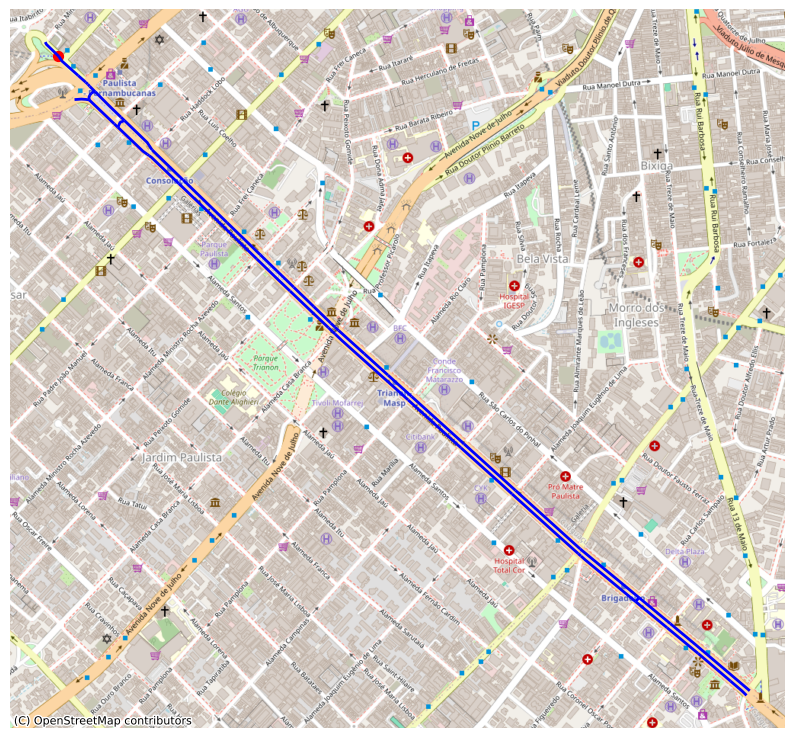

In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

gdf_segmentos_sirgas = gdf_segmentos.set_crs("EPSG:31983", allow_override=True)
gdf_ponto_sirgas = gpd.GeoDataFrame(geometry=[ponto], crs="EPSG:31983")

gdf_segmentos_3857 = gdf_segmentos_sirgas.to_crs(epsg=3857)
gdf_ponto_3857 = gdf_ponto_sirgas.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_segmentos_3857.plot(ax=ax, color='blue', linewidth=2)
gdf_ponto_3857.plot(ax=ax, color='red', markersize=50)

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

plt.axis('off')
plt.show()

In [15]:
gdf_ponto_3857.to_crs(epsg=4326)

,geometry
0,POINT (-46.66367 -23.55488)
